# C题问题二：参数来源增强 V2 全年实验

本笔记本在现有 Team-A 预测—储能调度方案上补齐参数来源、时间因果性、后置验证和终端 SOC 核算。本次不读取 V1 的 daily/summary/cache 结果，证据链为

\[
\text{数据审计}\to\text{因果预测与残差}\to\text{风险净负荷}
\to\text{日前 LP}\to\text{日内因果执行}
\to\text{滚动搜索/独立验收}\to\text{全年回测}\to\text{稳健性检验}.
\]

正式 `result2.xlsx` 不被覆盖；代码和原始数据 SHA256 写入运行清单。

## 1. 问题分析、数据清洗和信息集

附件2给出365天、每天144个10分钟时槽的负荷 $L_{d,t}$ 和光伏 $P_{d,t}$，$\Delta t=1/6$ h。规划与执行统一使用

\[
N_{d,t}=(L_{d,t}-P_{d,t})\Delta t\quad(\mathrm{kWh/slot}).
\]

每天0:00的决策只能使用 $\mathcal I_d=\{L_{j,t},P_{j,t}:j<d\}$ 及已知电价。清洗检查表头、日期连续性、144时槽完整性、缺失/非有限值和非负性；不主观删除真实尖峰。

In [ ]:
from pathlib import Path
import os, sys, json, subprocess
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
PROJECT=Path('/content/CUMCM_2026_Last_Dance') if Path('/content/CUMCM_2026_Last_Dance').exists() else Path.cwd()
os.chdir(PROJECT); sys.path.insert(0,str(PROJECT/'code/q2_v2'))
print('project =',PROJECT); print('python =',sys.version)

project = /content/CUMCM_2026_Last_Dance
python = 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [ ]:
from utils import load_data, data_audit, BATTERY, DT, T
data=load_data(); audit=data_audit(data)
display(pd.DataFrame([{'field':k,**v} for k,v in audit.items() if isinstance(v,dict) and 'shape' in v]))
display(pd.DataFrame([audit['battery']]))
print(json.dumps({'source_directory':audit['source_directory'],
                  'source_sha256':audit['source_sha256'],
                  'time_convention':audit['time_convention']},ensure_ascii=False,indent=2))

,field,shape,missing,minimum,maximum
0,price,[144],0,0.3713,1.3952
1,q1_load,[144],0,3309.3934,5958.9696
2,q1_pv,[144],0,0.0000,7612.3160
3,load,"[365, 144]",0,1995.7176,7978.8849
4,pv,"[365, 144]",0,0.0000,10216.2000


,capacity,minimum,maximum,power,eta_c,eta_d,initial
0,12000.0,1200.0,10800.0,5000.0,0.9,0.9,6000.0


{
  "source_directory": "C题/附件",
  "source_sha256": {
    "._附件1.xlsx": "6082863eeb288fedefeda5c052fdf64302e589c9938e4446c7a4562ee2ddc0b3",
    "._附件2.xlsx": "6082863eeb288fedefeda5c052fdf64302e589c9938e4446c7a4562ee2ddc0b3",
    "附件1.xlsx": "66b87134f5ecccd68184d3539bb1293ef039f9e0fdd955a589b9bfa7f227c377",
    "附件2.xlsx": "2e95fd446bfafa0d8c59577b5c2e2ea8b3f1def20dde54a3062556f4da9b4c72"
  },
  "time_convention": "右端标签：00:10 对应 00:00-00:10；24:00 对应 23:50-24:00"
}


## 2. 因果预测、残差与风险输入

保留 V2 的 Team-A 预测主干：负荷成员为周期外推与带星期虚拟变量的趋势回归；光伏成员为5日均值、指数均值与晴空形状分解。成员权重仅用过去10个已结束日的误差学习：

\[
w_{m,d}=\frac{\exp(-8\tilde e_{m,d})}{\sum_j\exp(-8\tilde e_{j,d})},\qquad
\tilde e_{m,d}=e_{m,d}/\bar e_d.
\]

记 $\widehat N_{d,t}=(\widehat L_{d,t}-\widehat P_{d,t})\Delta t$，残差 $r_{j,t}=N_{j,t}-\widehat N_{j,t}$。规划输入为

\[
\widetilde N_{d,t}=\widehat N_{d,t}+S_s\!\left(Q_\alpha\{r_{j,t}:d-W\le j<d\}\right),
\]

其中 $S_s$ 是0/3/5点对称平滑。条件残差只用历史内的季节、星期和当日预测日总量选相似日，再以 $b\in[0,0.5]$ 与全局残差收缩，防止小样本条件分位数完全支配结果。

## 3. 日前线性规划与日内执行

时槽 $t$ 的决策变量为计划购电 $q_t$、充电 $c_t$、放电 $v_t$、弃电 $s_t$ 和时槽末 SOC $E_t$。

\[
\min \sum_{t=1}^{144}p_tq_t,
\qquad q_t+v_t-c_t-s_t=\widetilde N_{d,t},
\]
\[
E_t=E_{t-1}+\eta_cc_t-v_t/\eta_d,
\quad 0\le c_t,v_t\le5000\Delta t,
\]
\[
q_t,s_t\ge0,\quad1200\le E_t\le10800,
\quad E_0=E_d^{actual},\quad E_{144}=E_{target}.
\]

$\eta_c=\eta_d=0.9$。目标、平衡、SOC递推和边界都是线性的，因此 HiGHS LP 能对当前有限问题提供全局最优解和可行性证据，无需用 GA/PSO 替代。LSTM是预测器，也不是此线性调度问题的求解器。

实际执行每个时槽只读当前 $N_{d,t}$，缺电且储能不能再放时以 $z_t\ge0$ 紧急购电，实现成本是
\[
C_d=\sum_t p_tq_t+5p_tz_t.
\]

## 4. 参数来源、`near()` 与 CVaR 修正

参数明确分成题设物理量、历史数据学习量、事前协议和风险/经济口径。每月部署前用42天搜索、14天独立成本验收和1天embargo。

原 `score <= best*(1+0.1%)` 的带宽没有统计来源，已删除。现以搜索期最低费用候选 $m^*$ 为参考，对 $\delta_d=C_{m,d}-C_{m^*,d}$ 做7日循环块、2000次 Bootstrap；只有当 $\bar\delta$ 的90%区间下界 $\le0$ 时，候选才进入简约性打破平局集。这只是搜索正则化，不等于证明两模型等价。

14天下 $14(1-0.95)=0.7<1$，精确经验 CVaR95 必然等于worst-day。因此14天只评估平均成本改善，风险非劣性改用同一截止点前56天，此时尾部质量为 $56(1-0.95)=2.8$天。

In [ ]:
from q2_fused import PARAMETER_REGISTRY
display(pd.DataFrame(PARAMETER_REGISTRY))

,parameter,category,source,selection
0,battery/SOC/power/efficiency,题设物理参数,题目与附件直接给定,不参与寻优
1,alpha,数据学习参数,预先声明候选域 0.50–0.95；搜索段拟合、后置验证段验收,滚动时间验证
2,window,结构候选参数,14/21/28/42/56 天，均围绕 7 日周期构造,滚动时间验证
3,rho,数据学习参数,"[0,1] 等距离散为 0/0.25/0.5/0.75/1",滚动时间验证
4,smooth,结构候选参数,0/3/5 点：无平滑、弱平滑、中等平滑,滚动时间验证
5,similar-day blend,数据学习参数,0–0.5 以 0.1 为步长；条件残差样本更小，故不允许权重超过全局残差,搜索段选择+验证段验收
6,similar-day K,结构候选参数,14/21/28/42 天，均为完整周的整数倍,搜索段选择+验证段验收
7,42/14/1 temporal split,实验协议参数,6 周搜索 + 2 周成本后置验证 + 1 日信息隔离,事前固定，不按全年结果调节
8,near tie rule,统计选择规则,删除固定0.1%带宽；用7日循环块Bootstrap 90%区间判断候选相对最优者是否可区分,搜索段内只作简约性规则，部署仍须独立验证
9,one-grid update limit,稳定性规则,每次正式更新仅允许在预先声明网格上移动一档,事前固定，不按全年结果调节


## 5. 终端 SOC、库存价值和敏感性

$E_{target}=6000$ kWh 来自初始SOC和容量50%，是日前LP参考轨迹的边界假设，不是Q2明确要求实际每天回到6000。实际日末 SOC 被下一天继承。核算费用为

\[
C^{adj}=C^{raw}-v_E(E_{end}-E_{start}).
\]

主口径 $v_E=p_{min}/\eta_c$ 是用最低电价补回1 kWh电池内能量的成本；同时报告 $v_E=0$ 和 $v_E=\eta_dp_{max}$。库存价值只改核算，不改LP。对 $E_{target}\in\{1200,4800,6000,7200,10800\}$ 全年实际重跑：端点是题设保护边界，4800/7200是中心值的±10%容量扰动。

## 6. 对照与评价体系

对照是旧GitHub的 **Ridge + H1-replan**。冻结其预测明细以保持比较器不变，但不读取V1逐日费用、SOC、summary或cache；在本次环境中重新求解21日场景、14日半衰期SAA和全年H1因果执行。

评价包括计划费、紧急费、总费用、紧急电量/时槽/日/事件频率、弃电量、CVaR90/95、最坏日、计算时间和7/14/28日块Bootstrap。分报2—12月全期、6—10月开发期和11—12月冻结检查期。

验收检查电量平衡、SOC递推/边界/跨日连续、功率上界、非负性、同时充放电、费用重算、参数更新限制和11—12月冻结。改加当日及未来观测的时间前缀检验要求当日决策输入完全不变。

In [ ]:
# 主计算：仅清空本版专属输出目录，再从头跑 user/fused/Ridge/敏感性/验收。
cmd=[sys.executable,'code/q2_v2/q2_fused.py','--stage','all']
print('RUN:', ' '.join(cmd),flush=True)
subprocess.run(cmd,check=True)

RUN: /usr/bin/python3 code/q2_v2/q2_fused.py --stage all


CompletedProcess(args=['/usr/bin/python3', 'code/q2_v2/q2_fused.py', '--stage', 'all'], returncode=0)

In [ ]:
# 只使用本次输出构建论文图表和数据驱动报告。
subprocess.run([sys.executable,'code/q2_v2/build_delivery_v2.py'],check=True)

CompletedProcess(args=['/usr/bin/python3', 'code/q2_v2/build_delivery_v2.py'], returncode=0)

## 7. 全年结果、成本分解与月度稳定性

以下数字由本次 Colab 输出现场读取，不手工填写。

,strategy,period,days,total_cost,planned_cost,emergency_cost,planned_kwh,emergency_kwh,spill_kwh,charge_kwh,...,emergency_slot_frequency,emergency_day_frequency,events,daily_cvar90,daily_cvar95,worst_day,initial_soc,terminal_soc,inventory_value_rate,adjusted_cost
22,ridge_h1_replan,development153,153,6.423977e+06,6.217861e+06,206115.824954,1.006225e+07,33044.277277,1.411502e+06,2.855339e+06,...,0.015341,0.477124,133,59972.085467,63590.045089,83280.629027,7435.284268,6144.526913,0.412556,6.424509e+06
7,fused,development153,153,6.557429e+06,6.179068e+06,378360.933205,9.976546e+06,62348.129227,1.351230e+06,2.869627e+06,...,0.024056,0.450980,131,66392.788172,73797.423241,99237.231936,6989.860069,6980.807925,0.412556,6.557433e+06
16,loose_gate,development153,153,6.557429e+06,6.179068e+06,378360.933205,9.976546e+06,62348.129227,1.351230e+06,2.869627e+06,...,0.024056,0.450980,131,66392.788172,73797.423241,99237.231936,6989.860069,6980.807925,0.412556,6.557433e+06
1,baseline,development153,153,6.564627e+06,6.169039e+06,395587.826585,9.964702e+06,65178.524725,1.341514e+06,2.873406e+06,...,0.024782,0.450980,134,66543.919537,74301.620993,99237.231936,6989.860069,6963.175694,0.412556,6.564638e+06
10,no_conditional,development153,153,6.564627e+06,6.169039e+06,395587.826585,9.964702e+06,65178.524725,1.341514e+06,2.873406e+06,...,0.024782,0.450980,134,66543.919537,74301.620993,99237.231936,6989.860069,6963.175694,0.412556,6.564638e+06
19,strict_gate,development153,153,6.564627e+06,6.169039e+06,395587.826585,9.964702e+06,65178.524725,1.341514e+06,2.873406e+06,...,0.024782,0.450980,134,66543.919537,74301.620993,99237.231936,6989.860069,6963.175694,0.412556,6.564638e+06
13,search_only,development153,153,6.586631e+06,6.169455e+06,417175.972195,9.964560e+06,68470.250445,1.344665e+06,2.873648e+06,...,0.025145,0.470588,139,68302.503806,76648.623071,99041.008000,6989.860069,6911.100716,0.412556,6.586663e+06
4,user,development153,153,6.595453e+06,6.154449e+06,441004.171479,9.948047e+06,72757.312072,1.331392e+06,2.879243e+06,...,0.028322,0.522876,158,69231.874804,77524.051682,99041.008000,6989.860069,6894.513152,0.412556,6.595492e+06
23,ridge_h1_replan,frozen61,61,2.931561e+06,2.908444e+06,23116.798150,4.692630e+06,4655.077188,2.919209e+05,1.333797e+06,...,0.005009,0.196721,17,65742.274628,67189.810330,71629.847652,6144.526913,6069.933521,0.412556,2.931592e+06
5,user,frozen61,61,2.944910e+06,2.884143e+06,60767.031064,4.660588e+06,11478.290282,2.650820e+05,1.345450e+06,...,0.010246,0.327869,32,69147.957948,73386.893040,83229.106802,6894.513152,6160.228460,0.412556,2.945213e+06


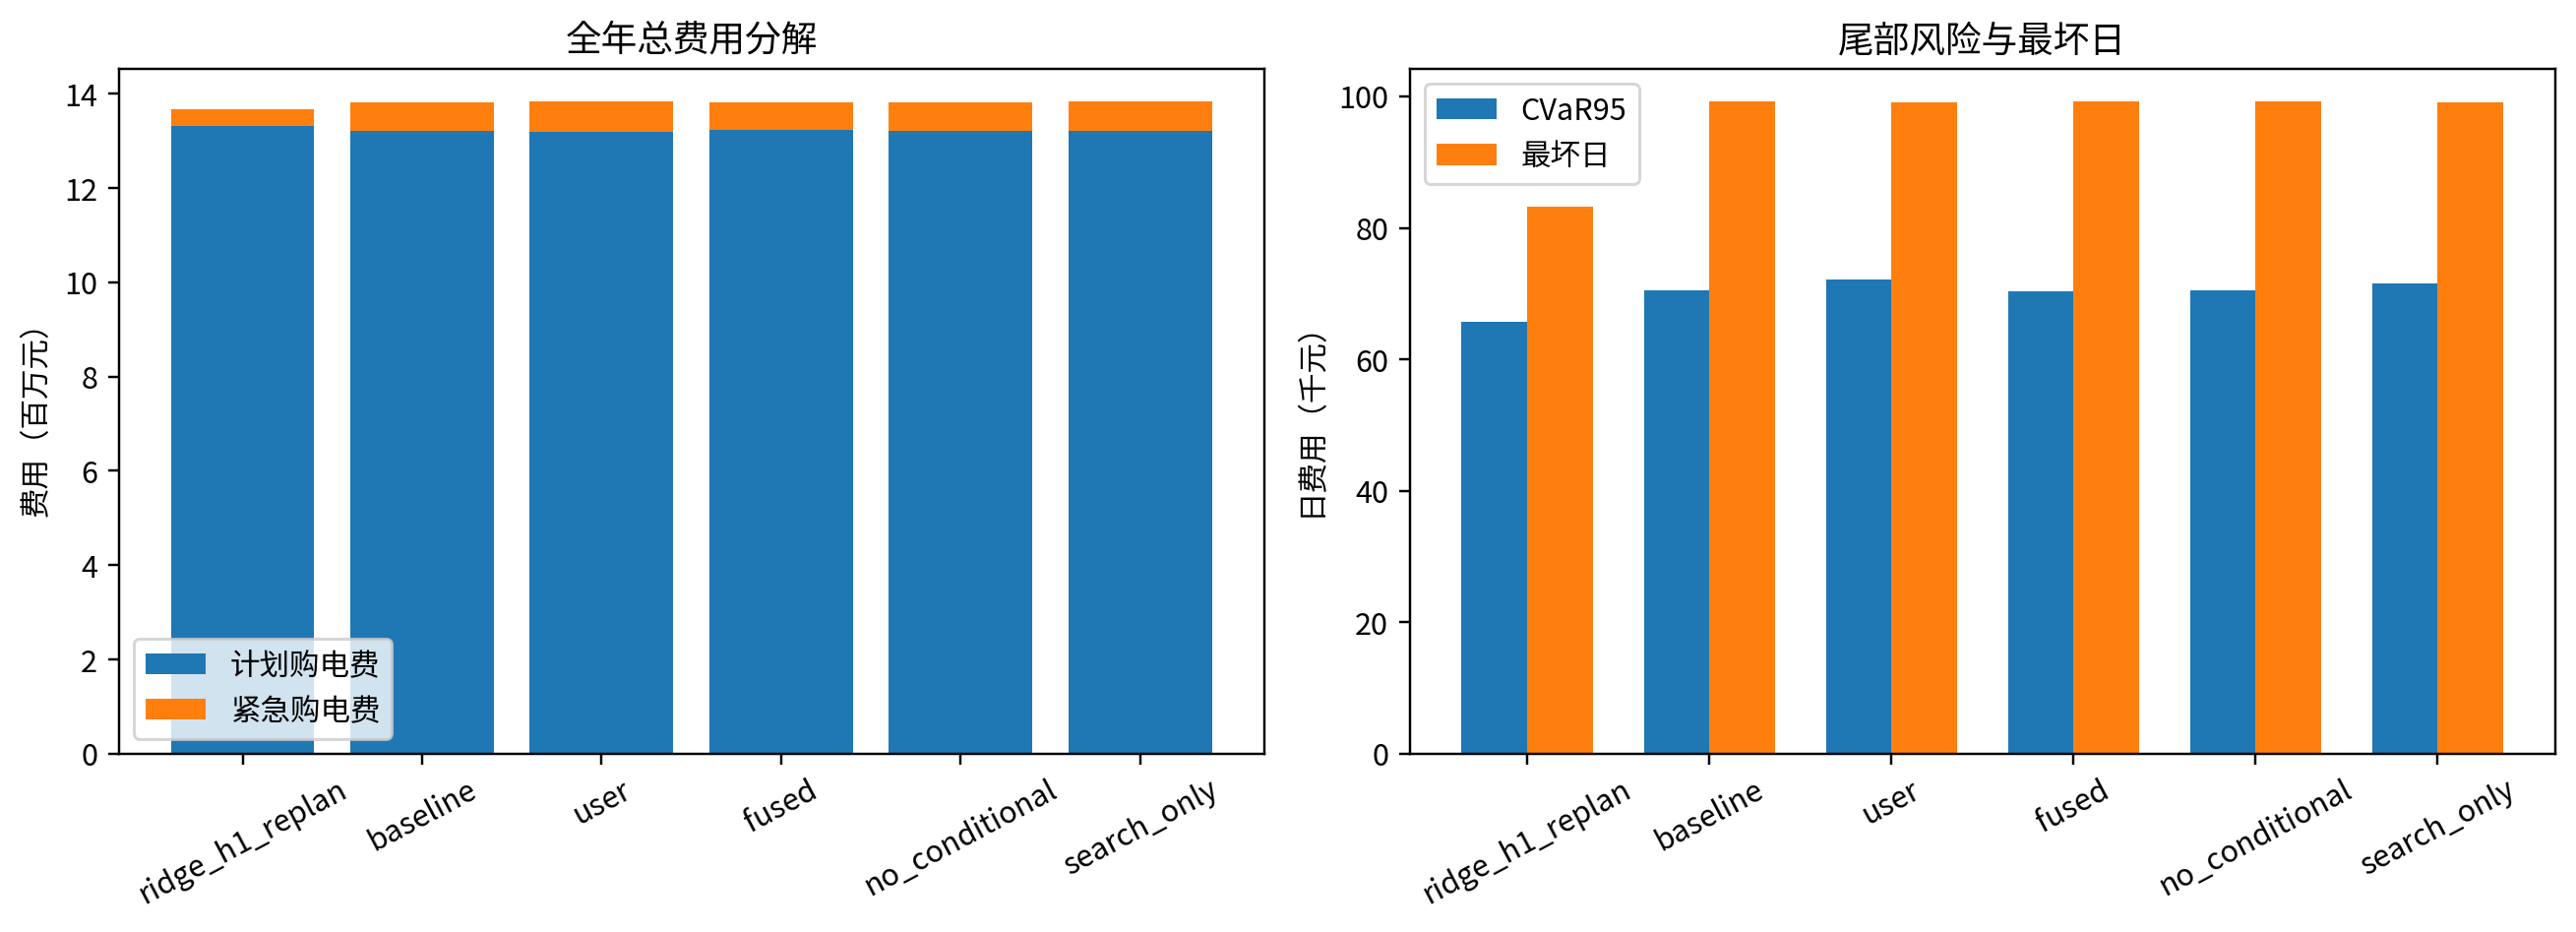

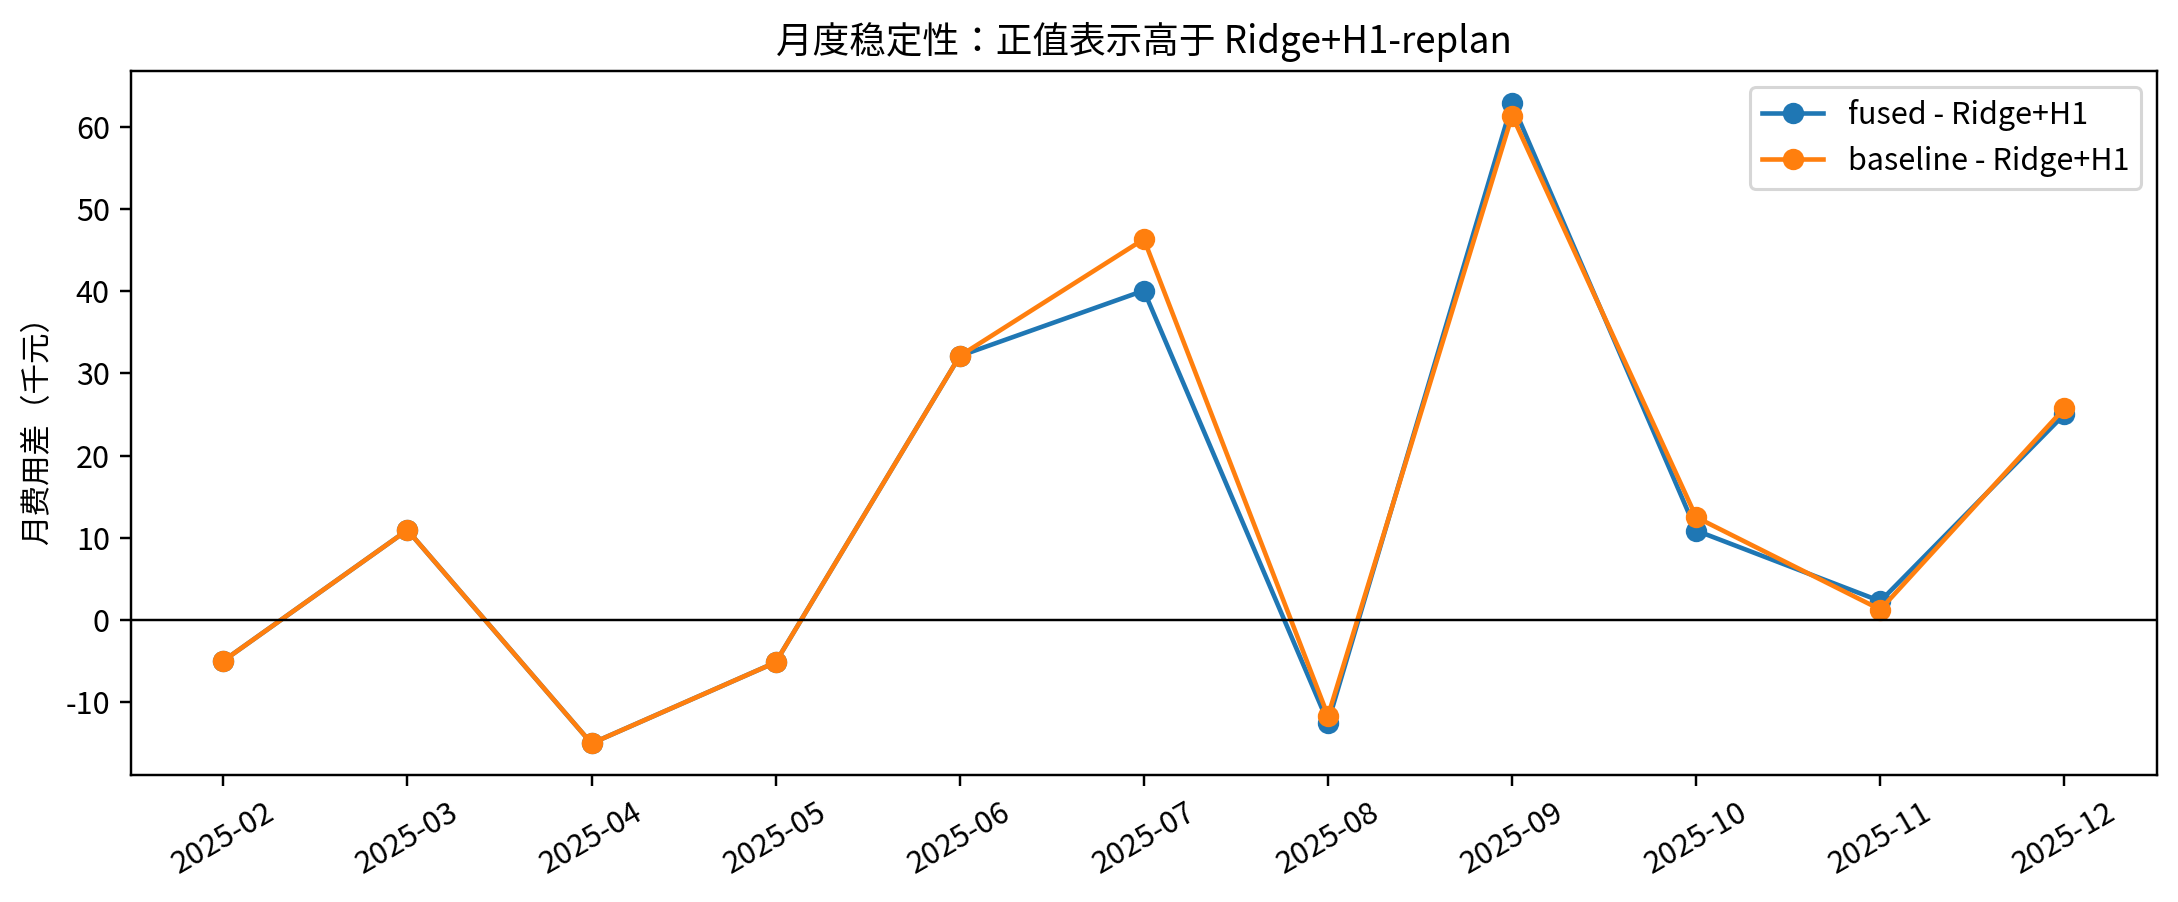

In [ ]:
R=PROJECT/'results/q2_fused_v2'; F=PROJECT/'figures/q2_fused_v2'
summary=pd.read_csv(R/'summary.csv'); display(summary.sort_values(['period','total_cost']))
display(Image(filename=str(F/'01_cost_and_risk.png')))
display(Image(filename=str(F/'02_monthly_stability.png')))

## 8. 参数更新、`near()` 和 Validation/CVaR 证据

表中保留每月候选、在位参数、Bootstrap区间、14天成本验收和56天风险验收。

,strategy,month,decision_date,fit_start,fit_end,embargo_date,validation_start,validation_end,incumbent_adjusted,candidate_adjusted,...,validation_new_worst_emergency,risk_validation_start,risk_validation_end,risk_observations,risk_tail_mass_days,old_emergency_cvar95,new_emergency_cvar95,accepted,gate_rule,reason
0,fused,6,2025-06-01,2025-04-05,2025-05-16,2025-05-31,2025-05-17,2025-05-30,437805.860300,443074.276345,...,11631.883083,2025-04-05,2025-05-30,56.0,2.8,16729.750378,18292.706533,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
1,fused,7,2025-07-01,2025-05-05,2025-06-15,2025-06-30,2025-06-16,2025-06-29,612889.782926,609989.713268,...,12681.745651,2025-05-05,2025-06-29,56.0,2.8,42641.710432,42585.638486,True,bootstrap_cost14_improvement_and_CVaR95_56_non...,accepted
2,fused,8,2025-08-01,2025-06-05,2025-07-16,2025-07-31,2025-07-17,2025-07-30,648479.189287,653215.008921,...,11714.750435,2025-06-05,2025-07-30,56.0,2.8,16152.997406,19670.285006,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
3,fused,9,2025-09-01,2025-07-06,2025-08-16,2025-08-31,2025-08-17,2025-08-30,601794.402032,604117.917719,...,15901.335667,2025-07-06,2025-08-30,56.0,2.8,12459.643595,14900.259206,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
4,fused,10,2025-10-01,2025-08-05,2025-09-15,2025-09-30,2025-09-16,2025-09-29,518952.436088,521623.078398,...,2256.053147,2025-08-05,2025-09-29,56.0,2.8,26184.505480,25778.476011,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
5,no_conditional,6,2025-06-01,2025-04-05,2025-05-16,2025-05-31,2025-05-17,2025-05-30,437805.860300,443074.276345,...,11631.883083,2025-04-05,2025-05-30,56.0,2.8,16729.750378,18292.706533,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
6,no_conditional,7,2025-07-01,2025-05-05,2025-06-15,2025-06-30,2025-06-16,2025-06-29,612889.782926,613068.177971,...,10313.773698,2025-05-05,2025-06-29,56.0,2.8,42641.710432,42583.795615,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
7,no_conditional,8,2025-08-01,2025-06-05,2025-07-16,2025-07-31,2025-07-17,2025-07-30,651377.674961,656191.067000,...,16267.257995,2025-06-05,2025-07-30,56.0,2.8,17893.372563,22752.836971,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
8,no_conditional,9,2025-09-01,2025-07-06,2025-08-16,2025-08-31,2025-08-17,2025-08-30,602291.249503,604117.917719,...,15901.335667,2025-07-06,2025-08-30,56.0,2.8,13147.814004,14900.259206,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold
9,no_conditional,10,2025-10-01,2025-08-05,2025-09-15,2025-09-30,2025-09-16,2025-09-29,519969.902319,523380.695553,...,2238.396718,2025-08-05,2025-09-29,56.0,2.8,25324.377491,26538.237492,False,bootstrap_cost14_improvement_and_CVaR95_56_non...,economic_gain_below_declared_threshold


,month,stage,candidates,indistinguishable,best_score
0,6,coarse,50,34,1.357981e+06
1,6,conditional,60,52,1.360222e+06
2,6,local,135,104,1.361824e+06
3,7,coarse,50,30,1.620628e+06
4,7,conditional,60,13,1.622532e+06
5,7,local,135,110,1.626759e+06
6,8,coarse,50,28,1.958906e+06
7,8,conditional,60,8,1.973903e+06
8,8,local,135,106,1.992352e+06
9,9,coarse,50,18,1.888684e+06


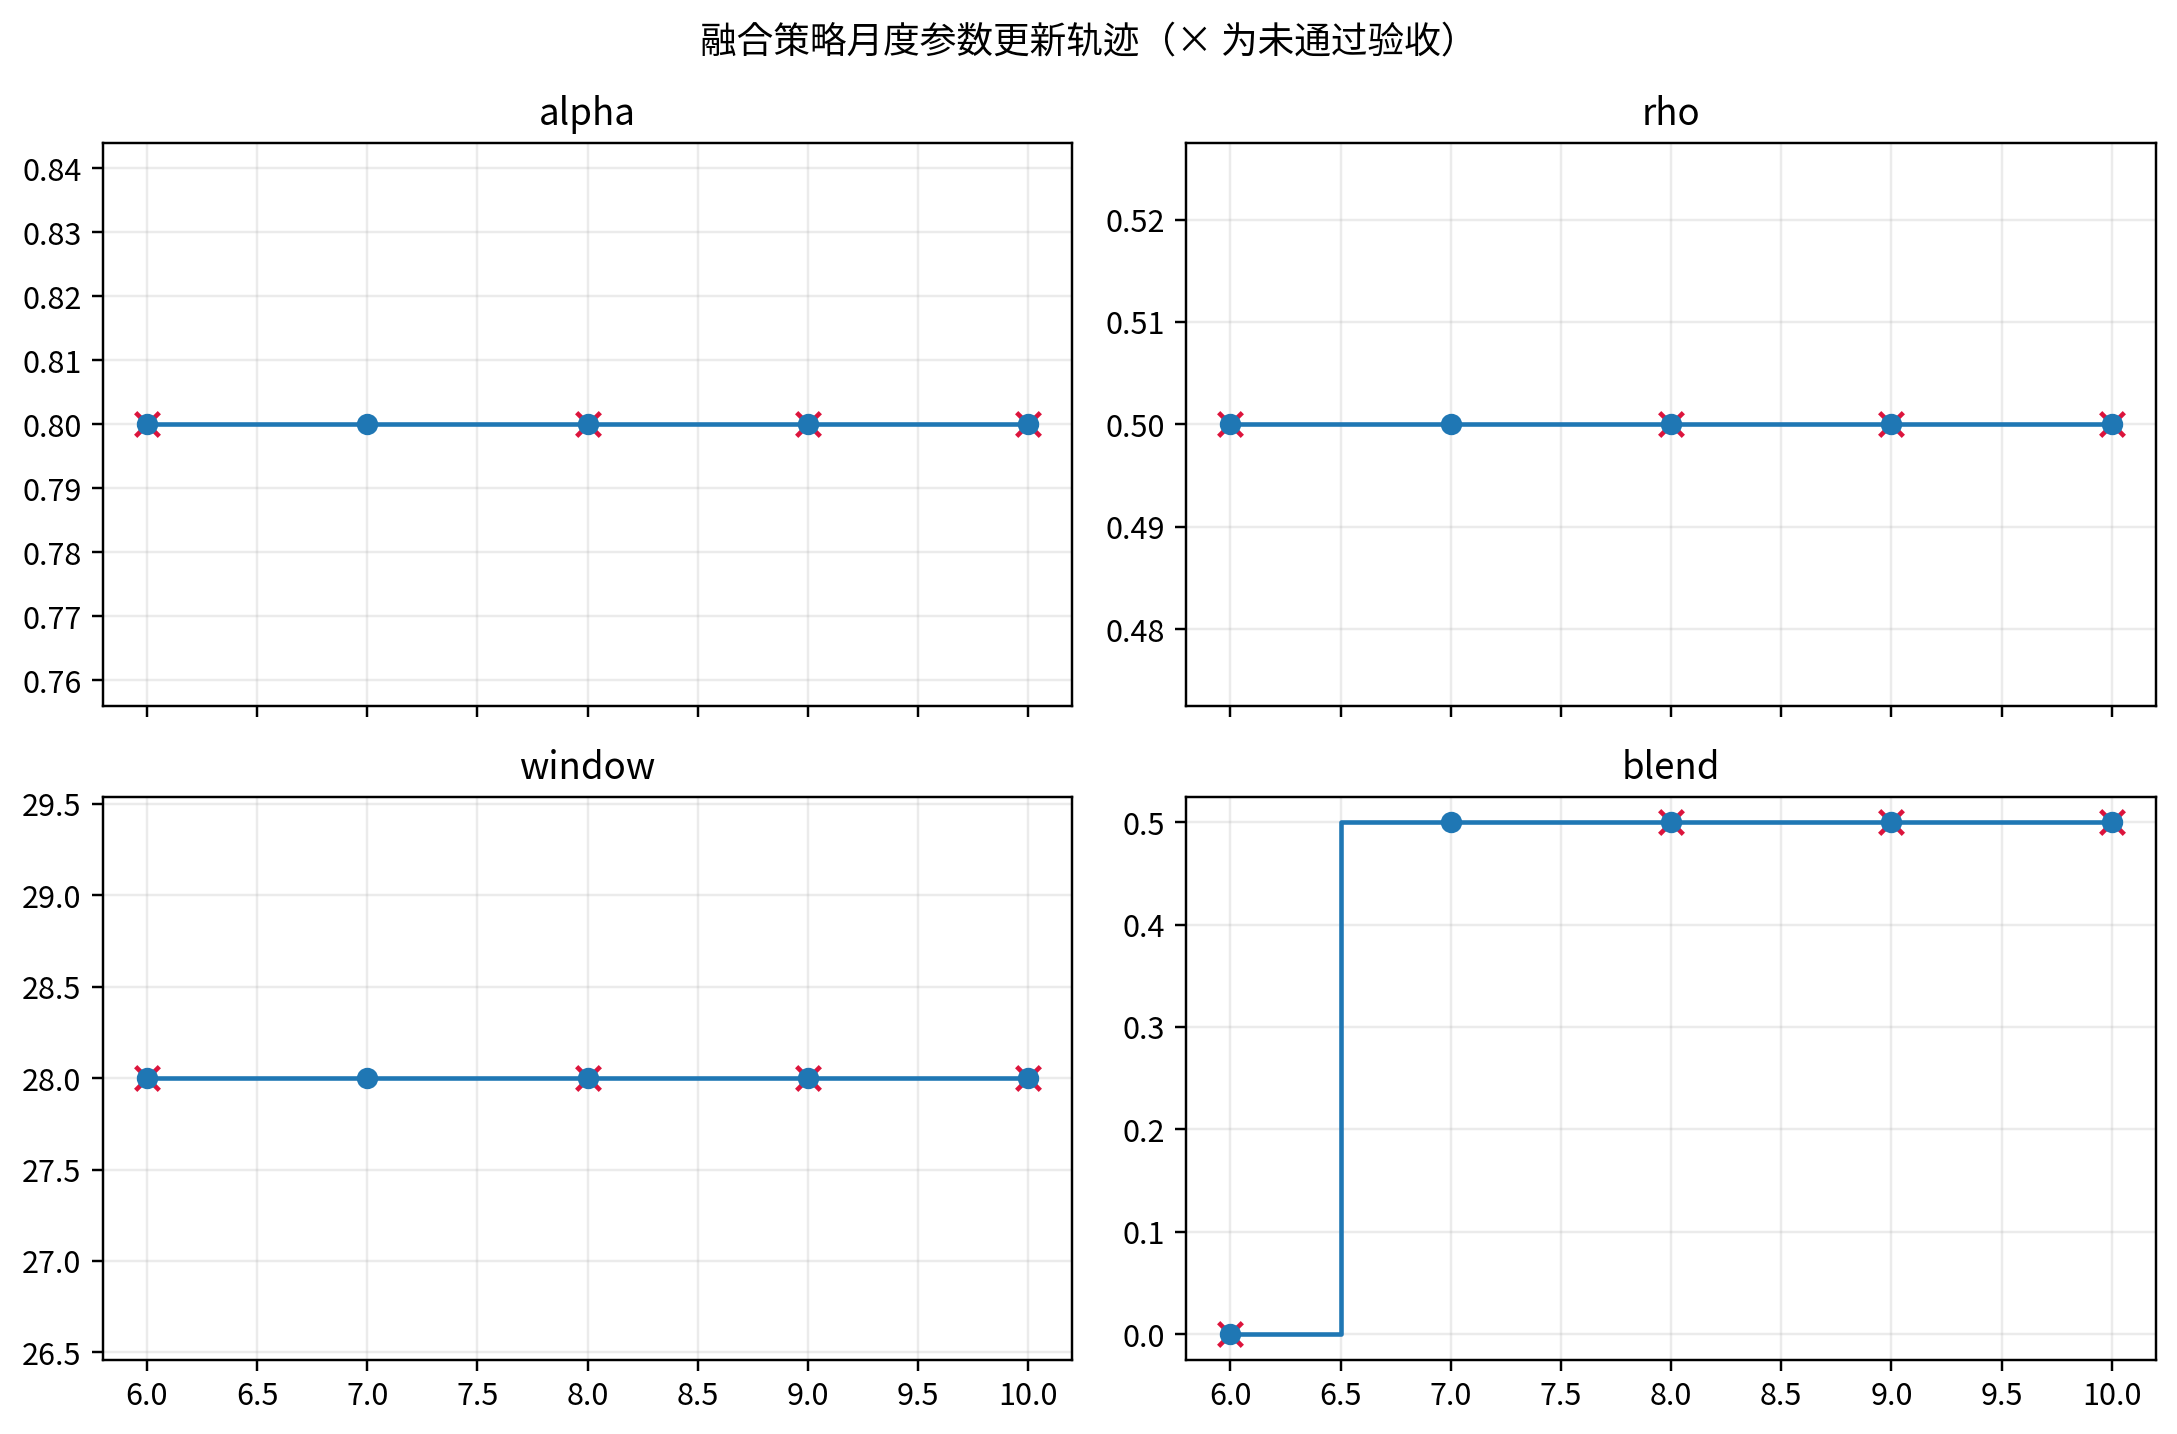

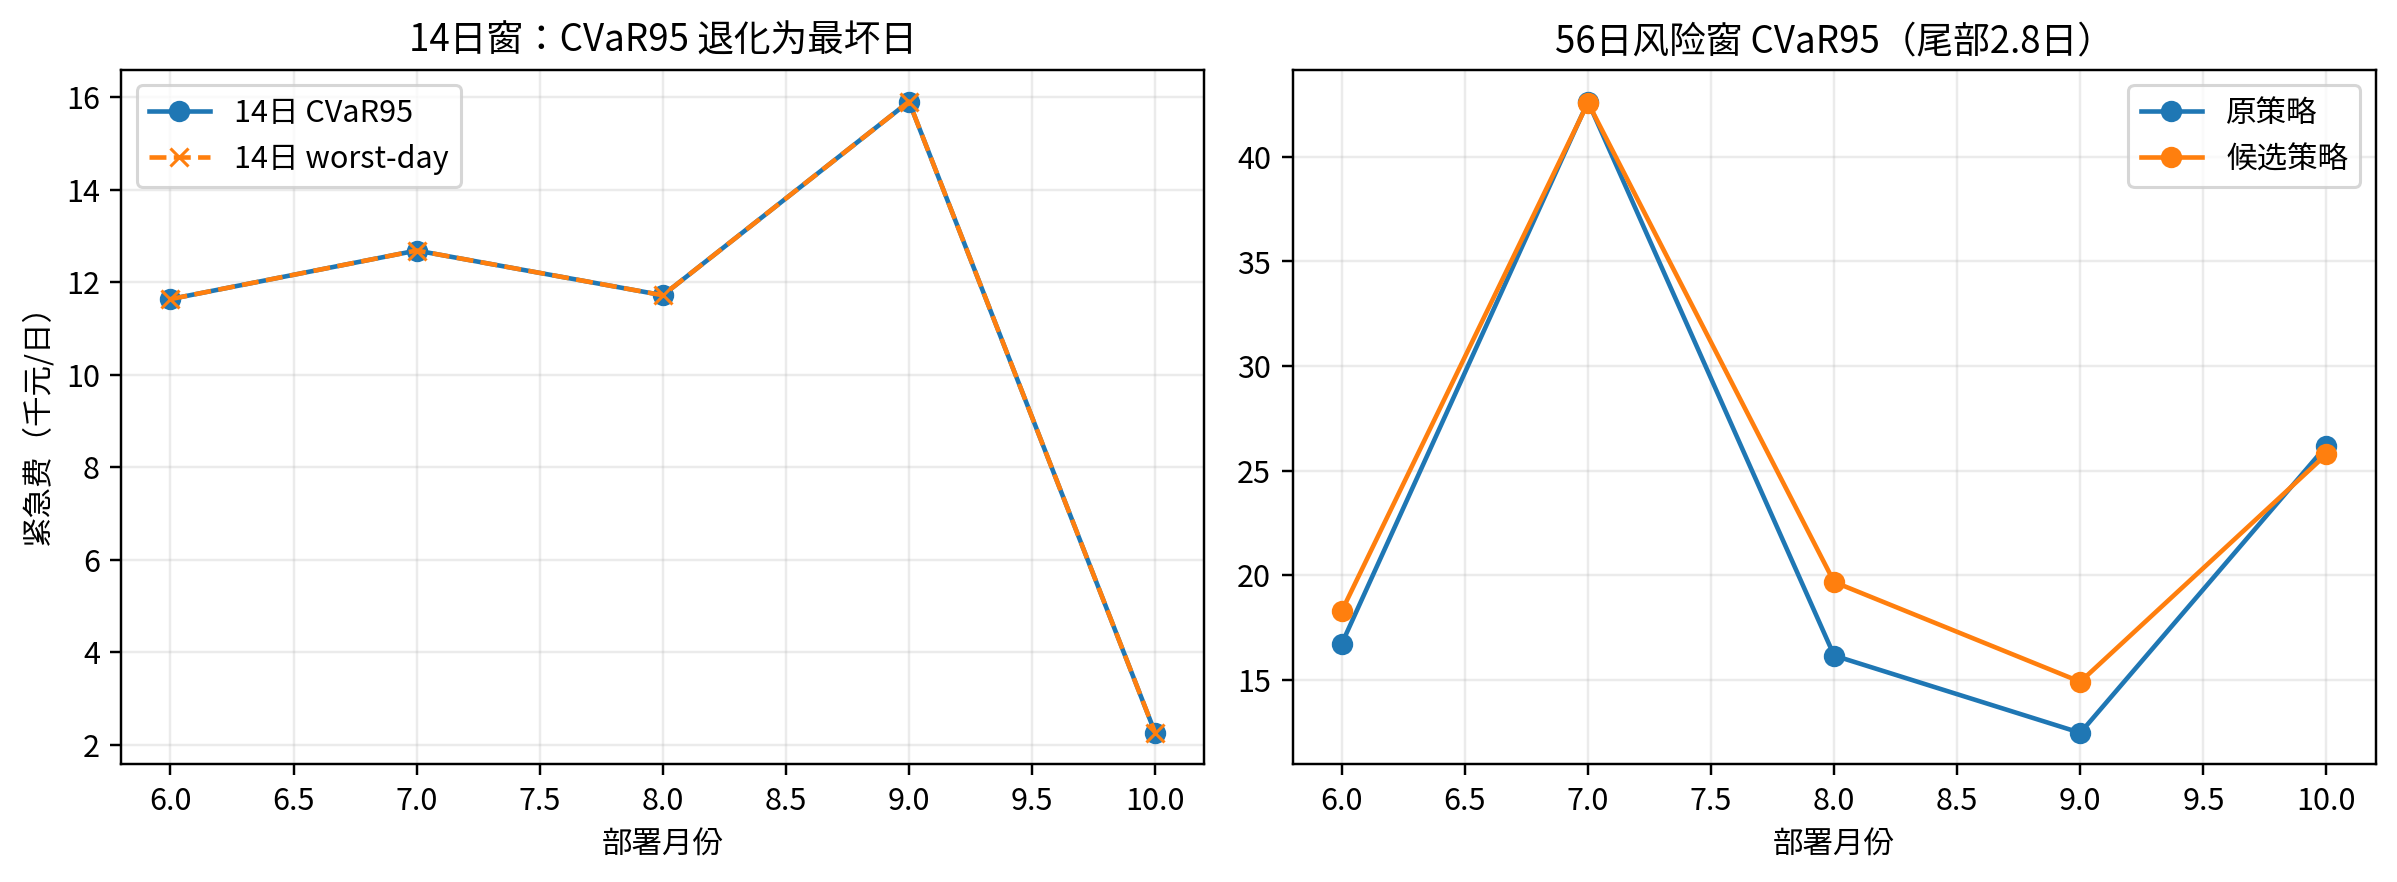

In [ ]:
display(pd.read_csv(R/'validation_diagnostics.csv'))
scores=pd.read_csv(R/'fused_scores.csv')
display(scores.groupby(['month','stage']).agg(candidates=('score','size'),
    indistinguishable=('near_indistinguishable','sum'),best_score=('score','min')).reset_index())
display(Image(filename=str(F/'03_parameter_path.png')))
display(Image(filename=str(F/'04_validation_and_cvar.png')))

## 9. $E_{target}$ 与期末库存价值敏感性

$E_{target}$ 敏感性是真实重跑，期末价值敏感性是对同一SOC轨迹的核算；两者不混淆。

,strategy,period,days,total_cost,planned_cost,emergency_cost,planned_kwh,emergency_kwh,spill_kwh,charge_kwh,...,events,daily_cvar90,daily_cvar95,worst_day,initial_soc,terminal_soc,inventory_value_rate,adjusted_cost,sensitivity_target,inventory_valuation
1,baseline,full334,334,1.381270e+07,1.318955e+07,623150.355990,2.149935e+07,109772.637471,2.475207e+06,6.309412e+06,...,271,66641.366644,70942.777663,101020.405316,6000.0,1487.262665,0.412556,1.381457e+07,1200.0,replacement
10,baseline,full334,334,1.380752e+07,1.320395e+07,603562.737107,2.157961e+07,100208.992599,2.521652e+06,6.420463e+06,...,240,66390.876401,70530.864847,99139.293428,6000.0,4989.448812,0.412556,1.380793e+07,4800.0,replacement
19,baseline,full334,334,1.382099e+07,1.321717e+07,603817.267181,2.161575e+07,100246.086341,2.543015e+06,6.493045e+06,...,240,66411.619301,70553.951841,99237.231936,6000.0,6123.302451,0.412556,1.382094e+07,6000.0,replacement
28,baseline,full334,334,1.383636e+07,1.323194e+07,604418.783976,2.165437e+07,100357.757676,2.564992e+06,6.575656e+06,...,240,66442.530194,70595.348682,99430.184621,6000.0,7299.421663,0.412556,1.383582e+07,7200.0,replacement
37,baseline,full334,334,1.397848e+07,1.336987e+07,608600.498415,2.195100e+07,101121.886848,2.814786e+06,6.809604e+06,...,241,66733.533073,70924.980409,100071.210480,6000.0,10800.000000,0.412556,1.397650e+07,10800.0,replacement
4,fused,full334,334,1.380642e+07,1.320228e+07,604139.726271,2.151422e+07,106369.166052,2.487606e+06,6.304401e+06,...,265,66510.911893,70697.560723,101020.405316,6000.0,1505.283690,0.412556,1.380828e+07,1200.0,replacement
13,fused,full334,334,1.380048e+07,1.321545e+07,585034.150514,2.159158e+07,97139.837415,2.531598e+06,6.414831e+06,...,234,66254.881604,70286.667747,99139.293428,6000.0,5015.421877,0.412556,1.380089e+07,4800.0,replacement
22,fused,full334,334,1.381407e+07,1.322883e+07,585242.947897,2.162804e+07,97169.831560,2.553323e+06,6.487204e+06,...,234,66276.102004,70311.348820,99237.231936,6000.0,6146.515661,0.412556,1.381401e+07,6000.0,replacement
31,fused,full334,334,1.382952e+07,1.324370e+07,585820.447654,2.166695e+07,97277.080386,2.575492e+06,6.570275e+06,...,234,66306.709761,70351.950041,99430.184621,6000.0,7321.540873,0.412556,1.382897e+07,7200.0,replacement
40,fused,full334,334,1.397368e+07,1.338320e+07,590484.326469,2.196716e+07,98131.523342,2.829128e+06,6.803467e+06,...,235,66605.918945,70690.579273,100071.210480,6000.0,10800.000000,0.412556,1.397170e+07,10800.0,replacement


,strategy,period,inventory_valuation,inventory_value_rate,raw_total_cost,initial_soc,terminal_soc,terminal_delta,adjusted_cost
0,baseline,full334,zero,0.000000,1.382099e+07,6000.0,6123.302451,123.302451,1.382099e+07
1,baseline,full334,replacement,0.412556,1.382099e+07,6000.0,6123.302451,123.302451,1.382094e+07
2,baseline,full334,avoidance_upper,1.255680,1.382099e+07,6000.0,6123.302451,123.302451,1.382083e+07
9,user,full334,zero,0.000000,1.383811e+07,6000.0,6160.228460,160.228460,1.383811e+07
10,user,full334,replacement,0.412556,1.383811e+07,6000.0,6160.228460,160.228460,1.383805e+07
11,user,full334,avoidance_upper,1.255680,1.383811e+07,6000.0,6160.228460,160.228460,1.383791e+07
18,fused,full334,zero,0.000000,1.381407e+07,6000.0,6146.515661,146.515661,1.381407e+07
19,fused,full334,replacement,0.412556,1.381407e+07,6000.0,6146.515661,146.515661,1.381401e+07
20,fused,full334,avoidance_upper,1.255680,1.381407e+07,6000.0,6146.515661,146.515661,1.381389e+07
27,no_conditional,full334,zero,0.000000,1.382099e+07,6000.0,6123.302451,123.302451,1.382099e+07


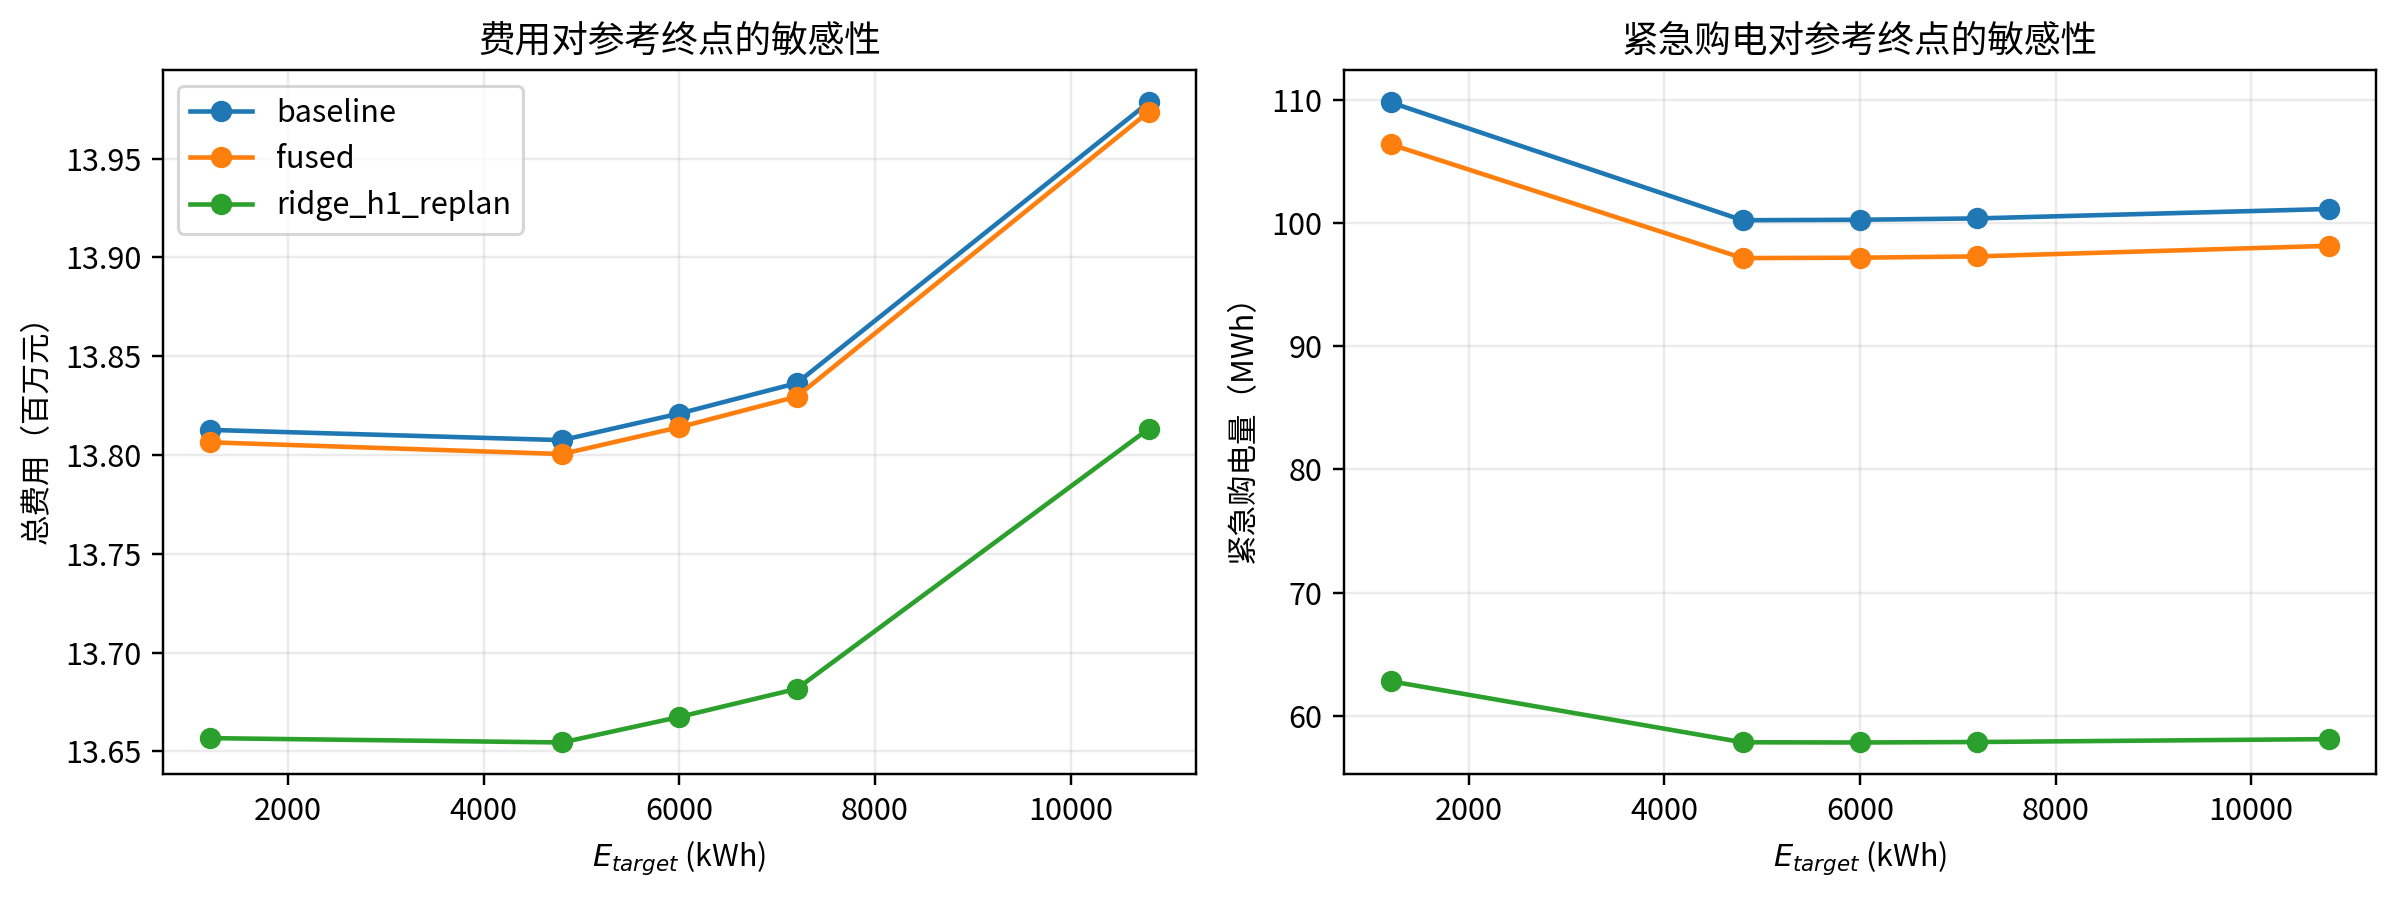

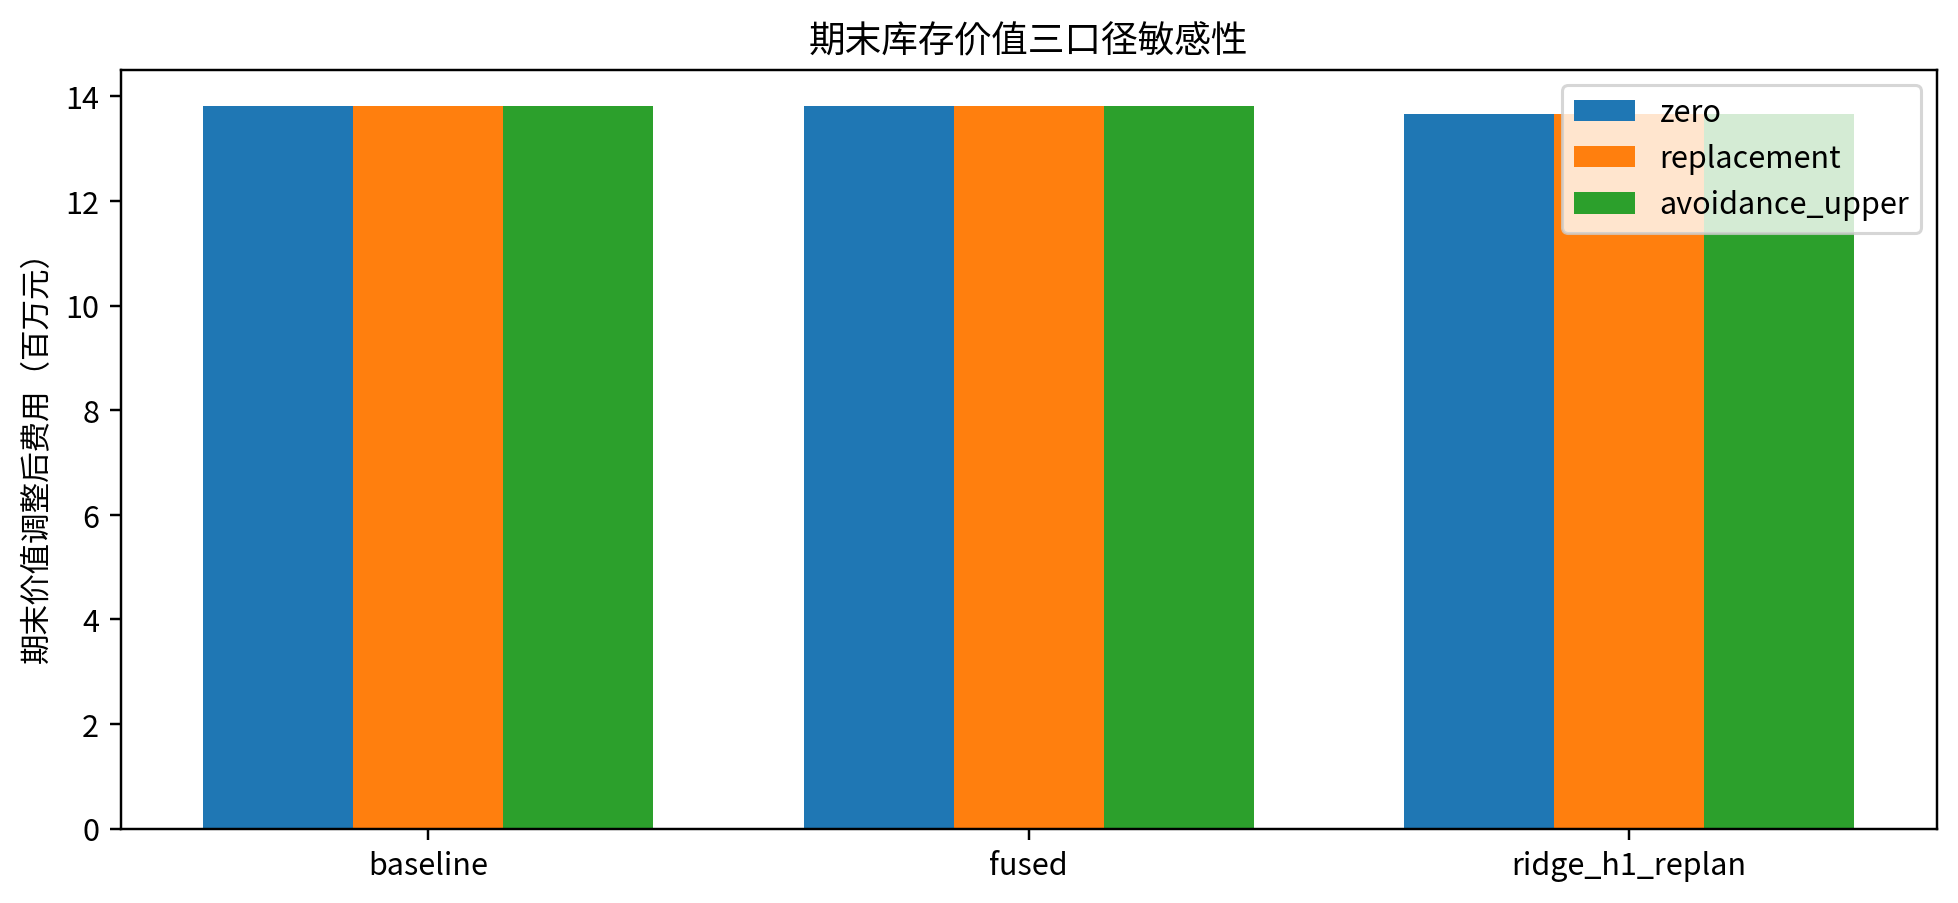

In [ ]:
target=pd.read_csv(R/'terminal_target_sensitivity.csv')
display(target[target.inventory_valuation=='replacement'].sort_values(['strategy','sensitivity_target']))
display(pd.read_csv(R/'inventory_value_sensitivity.csv').query("period=='full334'"))
display(Image(filename=str(F/'05_terminal_target_sensitivity.png')))
display(Image(filename=str(F/'06_inventory_value_sensitivity.png')))

## 10. Bootstrap、压力测试与验收

若费用差的区间跨过0，不将点估计的优势表述为稳健改进。冻结期是后期检查，但已被研究者查看，不夸大为真正未开封盲测。

,period,reference,candidate,block,daily_saving_mean,daily_saving_low95,daily_saving_high95,observed_total_saving,relative_saving
0,full334,ridge_h1_replan,fused,7,-439.009533,-887.132705,-26.048277,-146629.183855,-0.010728
1,full334,ridge_h1_replan,fused,14,-439.009533,-938.351678,12.643512,-146629.183855,-0.010728
2,full334,ridge_h1_replan,fused,28,-439.009533,-925.332557,5.930503,-146629.183855,-0.010728
3,full334,baseline,fused,7,20.707128,-19.705811,69.733865,6916.180623,0.000500
4,full334,baseline,fused,14,20.707128,-12.674250,63.493811,6916.180623,0.000500
5,full334,baseline,fused,28,20.707128,-7.423181,57.954685,6916.180623,0.000500
6,full334,user,fused,7,71.981572,-92.583467,252.598708,24041.844895,0.001737
7,full334,user,fused,14,71.981572,-91.873386,257.432891,24041.844895,0.001737
8,full334,user,fused,28,71.981572,-82.647855,252.200405,24041.844895,0.001737
9,development153,ridge_h1_replan,fused,7,-872.237096,-1704.145280,-102.363420,-133452.275617,-0.020774


,strategy,scenario,total_cost,daily_cvar90,daily_cvar95,emergency_kwh
0,baseline,实际,1.382099e+07,66411.619301,70553.951841,1.002461e+05
1,baseline,负荷+10%,2.516018e+07,121646.707682,130257.638363,2.135666e+06
2,baseline,光伏-30%,3.155032e+07,141999.379744,150467.108196,3.338467e+06
3,baseline,波动1.5倍,1.471805e+07,78650.225129,91118.257919,2.585327e+05
4,baseline,联合冲击,6.964246e+07,285798.058034,298497.536136,1.113828e+07
5,fused,实际,1.381407e+07,66276.102004,70311.348820,9.716983e+04
6,fused,负荷+10%,2.510325e+07,121418.181263,129894.638731,2.124017e+06
7,fused,光伏-30%,3.148430e+07,141559.941965,149980.489952,3.323162e+06
8,fused,波动1.5倍,1.470304e+07,78528.180072,90820.292172,2.538388e+05
9,fused,联合冲击,6.959208e+07,285399.243198,298070.541297,1.112465e+07


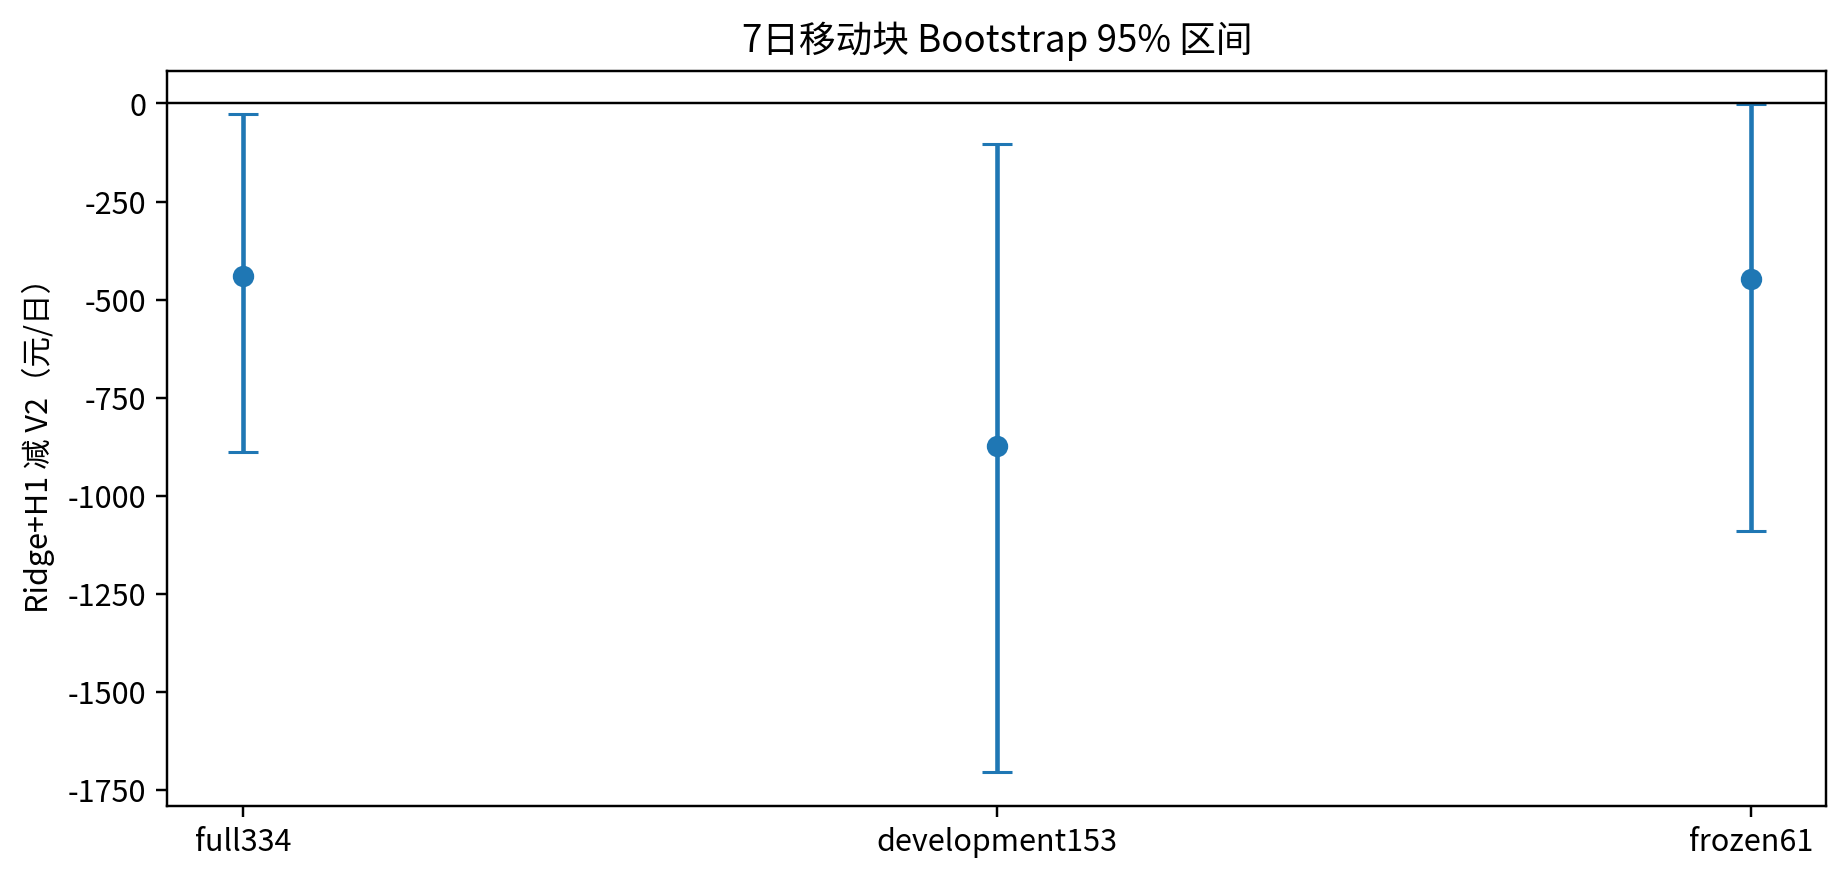

,test,passed,observed,max_difference_kwh,rows
0,baseline complete days,True,NaN,NaN,NaN
1,baseline continuous SOC,True,NaN,NaN,NaN
2,baseline settlement,True,NaN,NaN,NaN
3,user complete days,True,NaN,NaN,NaN
4,user continuous SOC,True,NaN,NaN,NaN
...,...,...,...,...,...
149,user_checks.csv physical,True,NaN,NaN,334.0
150,fused_checks.csv physical,True,NaN,NaN,2004.0
151,ridge_h1_replan_checks.csv physical,True,NaN,NaN,334.0
152,Etarget five-level coverage,True,NaN,NaN,NaN


ALL VERIFICATION TESTS PASSED: 154


In [ ]:
display(pd.read_csv(R/'bootstrap.csv')); display(pd.read_csv(R/'stress.csv'))
display(Image(filename=str(F/'07_bootstrap_vs_ridge.png')))
verification=json.loads((R/'verification.json').read_text())
display(pd.DataFrame(verification['tests']))
assert verification['all_pass'] and all(x['passed'] for x in verification['tests'])
print('ALL VERIFICATION TESTS PASSED:',verification['count'])

## 11. 局限与论文使用边界

- 单年回测不等于跨年泛化保证；56天CVaR95仍只含2.8个等权尾部日，所以同时报告CVaR90、worst-day和压力情景。
- `near()` 只是搜索段简约化，不是候选等价的证明。
- Ridge预测明细被冻结以保持对照定义；本次全新生成其规划、执行、SOC、费用和检验。
- GPU主要提供Colab高性能主机；HiGHS LP和Bootstrap为CPU计算，不声称GPU直接加速LP。
- “全局最优”只指已给定有限样本的LP，不外推到未知真实分布。

In [ ]:
run_manifest=json.loads((R/'run_manifest.json').read_text())
figure_manifest=json.loads((F/'figure_manifest.json').read_text())
print(json.dumps(run_manifest,ensure_ascii=False,indent=2)); display(pd.DataFrame(figure_manifest))
display(Markdown((PROJECT/'reports/Q2_FUSED_V2_RESULTS.md').read_text()))

{
  "fresh_run": true,
  "complete": true,
  "generated_utc": "2026-09-11T12:04:56.715241+00:00",
  "python": "3.13.15",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scipy": "1.15.3",
  "code_sha256": "4fdca838417aae8e9ba954d2f4d75237230eb2ec8d448109c42f78629b847f65",
  "inputs": {
    "C题/附件/附件1.xlsx": "66b87134f5ecccd68184d3539bb1293ef039f9e0fdd955a589b9bfa7f227c377",
    "C题/附件/附件2.xlsx": "2e95fd446bfafa0d8c59577b5c2e2ea8b3f1def20dde54a3062556f4da9b4c72",
    "results/problem2_forecast_ablation_predictions.csv.gz": "d6a5e9eee4131debec4e14d5eb15ab1477ab8504f3ef342bcd99d9a3408e9550"
  },
  "v1_result_files_used": false,
  "ridge_prediction_artifact_used": true,
  "official_result2_overwritten": false,
  "interpretation": "finite-sample LP optimality only; no claim of optimality under the unknown population distribution"
}


,figure,meaning
0,01_cost_and_risk,同时展示计划费、紧急费、CVaR95 和最坏日，避免只看总费用。
1,02_monthly_stability,检查优势是否只来自少数月份。
2,03_parameter_path,展示参数是否频繁波动、更新是否被后置验收拒绝。
3,04_validation_and_cvar,直观证明14日CVaR95信息量不足，并展示用于验收的56日风险证据。
4,05_terminal_target_sensitivity,每个Etarget均重新规划与因果执行，而非事后换算。
5,06_inventory_value_sensitivity,说明期末SOC价值是核算假设，不是凭空获得的唯一真值。
6,07_bootstrap_vs_ridge,区分观测差额与在周相关下仍可支持的稳健差异。


# Q2 参数来源增强 V2：全年重跑结果

> 本报告只读取 `results/q2_fused_v2` 本次运行的输出。`run_manifest.json` 声明
> `fresh_run=true` 且未读取 V1 daily/summary 结果。Ridge 预测明细被作为已冻结比较器输入，
> 其 H1-replan 规划、SOC 轨迹和费用已全部重新求解。

## 核心结果

| strategy | total_cost | planned_cost | emergency_cost | emergency_kwh | daily_cvar95 | worst_day | adjusted_cost |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ridge_h1_replan | 13,667,441.21 | 13,310,756.96 | 356,684.25 | 57,851.70 | 65,682.59 | 83,280.63 | 13,667,412.36 |
| fused | 13,814,070.40 | 13,228,827.45 | 585,242.95 | 97,169.83 | 70,311.35 | 99,237.23 | 13,814,009.95 |
| loose_gate | 13,814,070.40 | 13,228,827.45 | 585,242.95 | 97,169.83 | 70,311.35 | 99,237.23 | 13,814,009.95 |
| baseline | 13,820,986.58 | 13,217,169.31 | 603,817.27 | 100,246.09 | 70,553.95 | 99,237.23 | 13,820,935.71 |
| strict_gate | 13,820,986.58 | 13,217,169.31 | 603,817.27 | 100,246.09 | 70,553.95 | 99,237.23 | 13,820,935.71 |
| no_conditional | 13,820,986.58 | 13,217,169.31 | 603,817.27 | 100,246.09 | 70,553.95 | 99,237.23 | 13,820,935.71 |
| search_only | 13,835,230.92 | 13,208,282.32 | 626,948.60 | 103,806.50 | 71,558.97 | 99,041.01 | 13,835,171.64 |
| user | 13,838,112.24 | 13,183,996.56 | 654,115.68 | 108,680.65 | 72,090.05 | 99,041.01 | 13,838,046.14 |

V2 fused 全年实际费用为 **13,814,070.40 元**，冻结 Ridge+H1-replan 比较器为
**13,667,441.21 元**，实际差额（Ridge 减 V2）为 **-146,629.18 元**。
该句只是同日回测差额；是否能推荐替换，还要同时看开发期、冻结期和 Bootstrap 区间。

## `near()` 与验证门

原固定 0.1% 近似并列带宽已删除。现对搜索期候选与搜索期最低费用候选的逐日费用差
作 7 日循环移动块 Bootstrap；若“候选减最优”均值的 90% 区间下界不大于0，
则尚无证据说明它更差，才进入简约性打破平局集合。这只是搜索段正则化，部署仍需独立的
14 日费用改善证据和 56 日 CVaR95 非劣性。

| month | accepted | relative_improvement | bootstrap_daily_low90 | bootstrap_daily_high90 | validation_new_emergency_cvar95 | validation_new_worst_emergency | new_emergency_cvar95 | risk_tail_mass_days |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 6 | False | -0.0120 | -593.2841 | -135.5557 | 11,631.8831 | 11,631.8831 | 18,292.7065 | 2.8000 |
| 7 | True | 0.0047 | 47.6337 | 366.6619 | 12,681.7457 | 12,681.7457 | 42,585.6385 | 2.8000 |
| 8 | False | -0.0073 | -516.3778 | -164.1195 | 11,714.7504 | 11,714.7504 | 19,670.2850 | 2.8000 |
| 9 | False | -0.0039 | -337.7085 | 5.7777 | 15,901.3357 | 15,901.3357 | 14,900.2592 | 2.8000 |
| 10 | False | -0.0051 | -282.6401 | -97.8639 | 2,256.0531 | 2,256.0531 | 25,778.4760 | 2.8000 |

14 日时，$14(1-0.95)=0.7<1$，故精确经验 CVaR95 必然等于最坏日，不能提供独立尾部信息。
56 日窗有 $56(1-0.95)=2.8$ 个等权尾部日，因此改用它检查风险非劣性。

## 期末 SOC 与库存价值

$E_{target}$ 是日前 LP 参考 SOC 轨迹的终点，不是实际执行必须回到的日末 SOC；
实际 SOC 逐日连续继承。主核算使用 $v_E=p_{min}/\eta_c$，即以最低电价补回一单位电池内能量的成本；
同时报告 $v_E=0$ 和 $v_E=\eta_d p_{max}$。它们是经济核算边界，不冒充为数据学习的风险偏好。

| strategy | sensitivity_target | total_cost | adjusted_cost | emergency_kwh | daily_cvar95 | terminal_soc |
| --- | --- | --- | --- | --- | --- | --- |
| baseline | 1,200.00 | 13,812,704.77 | 13,814,566.53 | 109,772.64 | 70,942.78 | 1,487.26 |
| fused | 1,200.00 | 13,806,423.72 | 13,808,278.04 | 106,369.17 | 70,697.56 | 1,505.28 |
| ridge_h1_replan | 1,200.00 | 13,656,716.58 | 13,658,598.61 | 62,821.39 | 65,779.41 | 1,438.12 |
| baseline | 4,800.00 | 13,807,516.38 | 13,807,933.29 | 100,208.99 | 70,530.86 | 4,989.45 |
| fused | 4,800.00 | 13,800,481.02 | 13,800,887.21 | 97,139.84 | 70,286.67 | 5,015.42 |
| ridge_h1_replan | 4,800.00 | 13,654,512.97 | 13,654,958.47 | 57,868.09 | 65,655.74 | 4,920.13 |
| baseline | 6,000.00 | 13,820,986.58 | 13,820,935.71 | 100,246.09 | 70,553.95 | 6,123.30 |
| fused | 6,000.00 | 13,814,070.40 | 13,814,009.95 | 97,169.83 | 70,311.35 | 6,146.52 |
| ridge_h1_replan | 6,000.00 | 13,667,441.21 | 13,667,412.36 | 57,851.70 | 65,682.59 | 6,069.93 |
| baseline | 7,200.00 | 13,836,356.18 | 13,835,820.10 | 100,357.76 | 70,595.35 | 7,299.42 |
| fused | 7,200.00 | 13,829,518.95 | 13,828,973.74 | 97,277.08 | 70,351.95 | 7,321.54 |
| ridge_h1_replan | 7,200.00 | 13,681,643.37 | 13,681,127.73 | 57,889.31 | 65,705.43 | 7,249.86 |
| baseline | 10,800.00 | 13,978,475.35 | 13,976,495.08 | 101,121.89 | 70,924.98 | 10,800.00 |
| fused | 10,800.00 | 13,973,682.19 | 13,971,701.92 | 98,131.52 | 70,690.58 | 10,800.00 |
| ridge_h1_replan | 10,800.00 | 13,813,294.69 | 13,811,314.43 | 58,124.91 | 66,028.52 | 10,800.00 |

## 稳健性与可复现性

- `bootstrap.csv` 给出 V2 相对 Ridge+H1-replan、固定 A 和原分阶段方案的 7/14/28 日块区间。
- `terminal_target_daily.csv.gz` 保留 5 个 $E_{target}$ 的逐日实际重跑轨迹。
- `inventory_value_sensitivity.csv` 保留三种库存价值口径。
- `verification.json` 检查时间前缀不变性、LP/执行物理可行性、SOC 连续性、费用重算、风险窗和参数冻结。
- 所有“全局最优”只针对已给定有限样本的线性规划，不外推到未知真实分布。
